In [2]:
import matplotlib
import numpy as np

from matplotlib import pyplot as plt
from model_tools import ModelAnalysis, RasterAnalysis
from PIL import Image

In [5]:
#Set plotting look and feel

host_color = matplotlib.colors.to_rgb('#558ADB')
path_color = matplotlib.colors.to_rgb('#FF4C32')
coevol_color = matplotlib.colors.to_rgb('#FFB91A')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", host_color])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", path_color])

plot_label_size = 12
axis_title_size = 12
axis_label_size = 8
tick_label_size = 6

matplotlib.rcParams['axes.titlesize'] = axis_title_size
matplotlib.rcParams['axes.labelsize'] = axis_label_size
matplotlib.rcParams['xtick.labelsize'] = tick_label_size
matplotlib.rcParams['ytick.labelsize'] = tick_label_size

matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{xfrac}'

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'Helvetica'
})

In [10]:
#Load rasters and data used for raster plots

#host_path = 'default data/host.p'
#path_path = 'default data/path.p'
#coevol_path = 'default data/coevol.p'

host_path = 'host_assorted.p'
path_path = 'path_assorted.p'
coevol_path = 'coevol_assorted.p'

host_raster = RasterAnalysis(host_path)
path_raster = RasterAnalysis(path_path)
coevol_raster = RasterAnalysis(coevol_path)

In [3]:
#Generate date for evolutionary simulation figures, for branching example use 'm':0.93, 'z':10

params = {'m':0.7, 'z':10, 'assort':1.25, 'N_iter':200}

host_model = ModelAnalysis(mode='host', **params)
path_model = ModelAnalysis(mode='path', **params)
coevol_model = ModelAnalysis(mode='coevol', **params)

## Figure 1: Trade-off Curves

Text(0, 0.5, 'adult transmission modifier ($h_j$)')

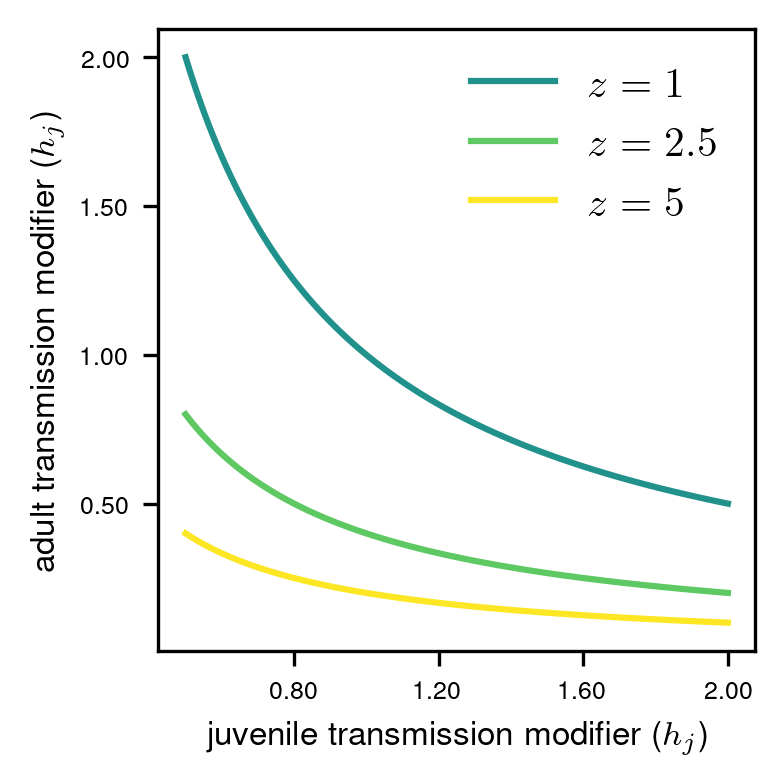

In [42]:
fig, ax = plt.subplots(figsize=(2.5, 2.5), layout='compressed')

cmap = matplotlib.colormaps['viridis']
colors = cmap(np.linspace(0, 1, 5))

def get_tradeoff(z):
    evol_range = 2
    resJ = np.logspace(-1, 1, 100, base=evol_range)
    resA = 1/(resJ*z)

    return resJ, resA

z1_j, z1_a = get_tradeoff(1)
z2_j, z2_a = get_tradeoff(2.5)
z3_j, z3_a = get_tradeoff(5)

ax.plot(z1_j, z1_a, color=colors[2], label=r'$z=1$')
ax.plot(z2_j, z2_a, color=colors[3], label=r'$z=2.5$')
ax.plot(z3_j, z3_a, color=colors[4], label=r'$z=5$')

ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
ax.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))

ax.legend(loc='upper right', frameon=False)

ax.set_xlabel(r'juvenile transmission modifier ($h_j$)')
ax.set_ylabel(r'adult transmission modifier ($h_j$)')

In [43]:
fig.savefig('figures/fig_1.svg', bbox_inches='tight')

## Figure 2: Evolutionary Simulation Examples

Text(-0.1, 1.1, 'F')

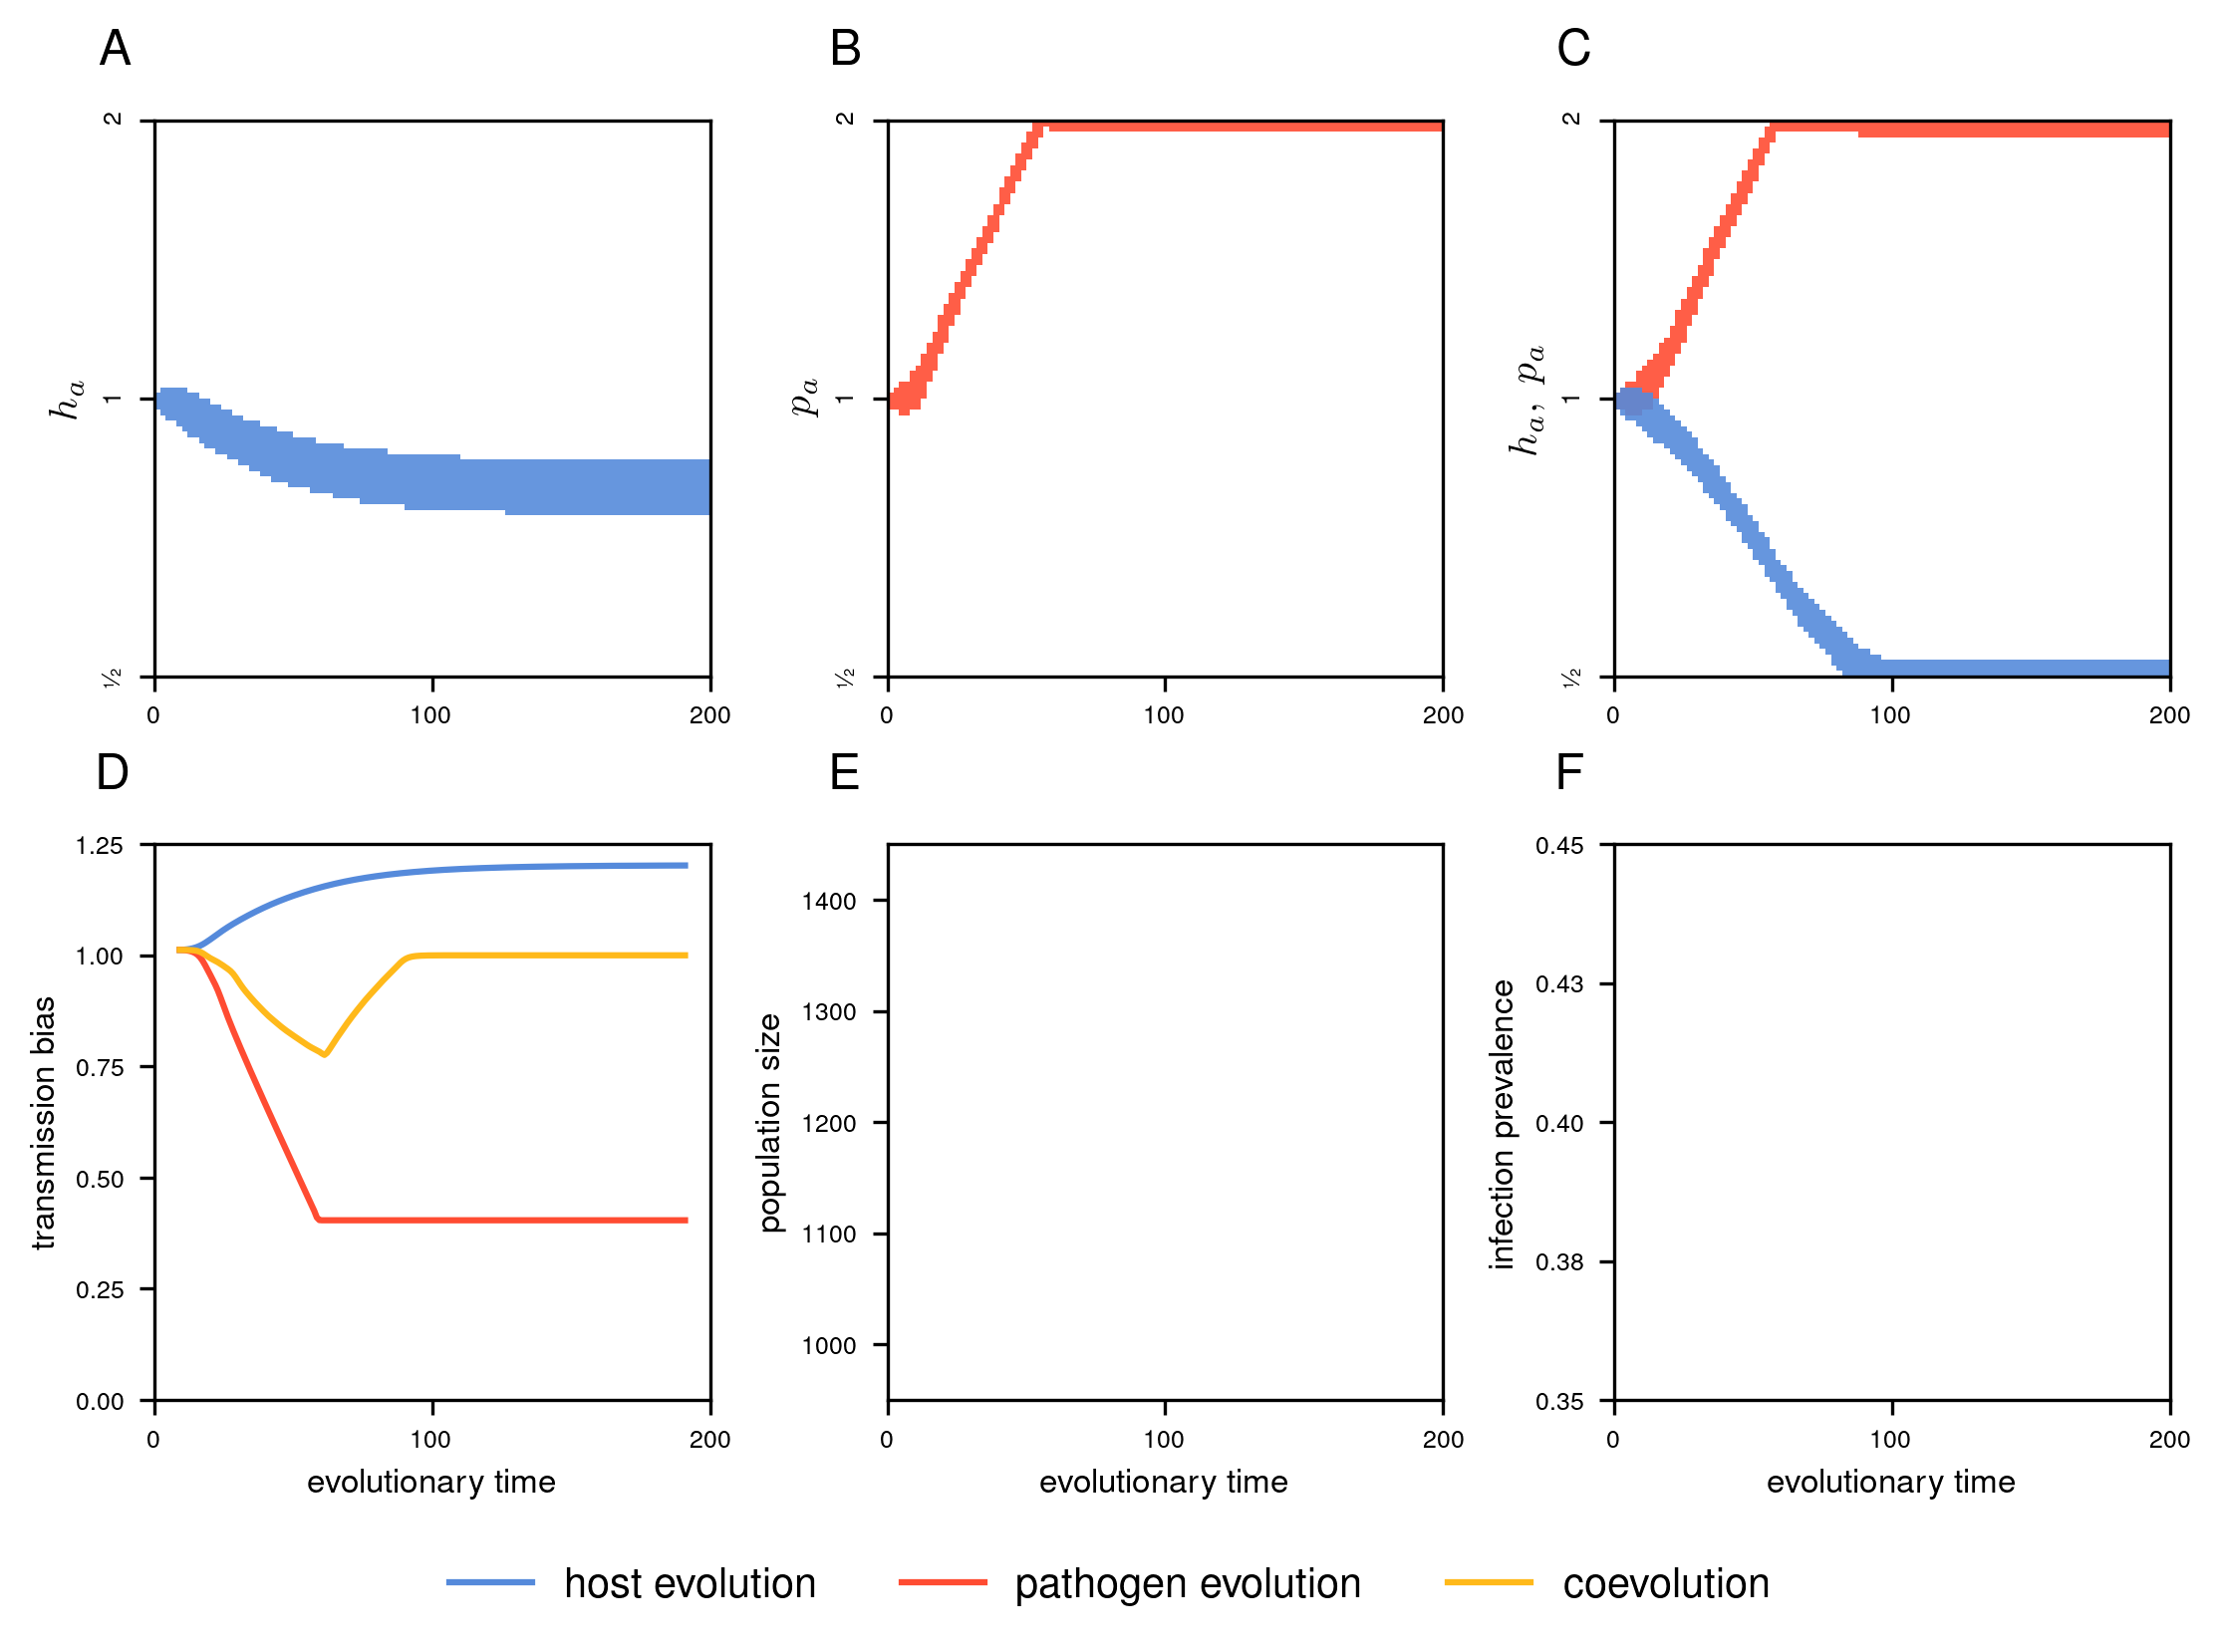

In [6]:
fig, ax = plt.subplots(figsize=(7.5,5), ncols=3, nrows=2, layout='compressed')

def make_image(Sa, Ia):
    Sa_img = Sa / np.max(Sa)
    Ia_img = Ia / np.max(Ia)
    Sa_img = np.array(Image.fromarray(Sa).resize(size=(100,100)))
    Ia_img = np.array(Image.fromarray(Ia).resize(size=(100,100)))
    Sa_img[Sa_img >= 0.2] = 1
    Sa_img[Sa_img < 0.2] = 0
    Ia_img[Ia_img >= 0.2] = 1
    Ia_img[Ia_img < 0.2] = 0

    Sa_alpha = np.ones(Sa_img.shape)*0.9
    Ia_alpha = np.ones(Ia_img.shape)*0.9
    Sa_alpha[Sa_img == 0] = 0
    Ia_alpha[Ia_img == 0] = 0

    return (Sa_img, Ia_img, Sa_alpha, Ia_alpha)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

Sa_img_h, Ia_img_h, Sa_alpha_h, Ia_alpha_h = make_image(host_model.Sa, host_model.Ia)
Sa_img_p, Ia_img_p, Sa_alpha_p, Ia_alpha_p = make_image(path_model.Sa, path_model.Ia)
Sa_img_c, Ia_img_c, Sa_alpha_c, Ia_alpha_c = make_image(coevol_model.Sa, coevol_model.Ia)

N_h = np.sum(host_model.Sj + host_model.Sa + host_model.Ij + host_model.Ia, axis=0)
N_p = np.sum(path_model.Sj + path_model.Sa + path_model.Ij + path_model.Ia, axis=0)
N_c = np.sum(coevol_model.Sj + coevol_model.Sa + coevol_model.Ij + coevol_model.Ia, axis=0)

ax[0,0].imshow(Sa_img_h, alpha=Sa_alpha_h, cmap=s_cmap)
ax[0,1].imshow(Ia_img_p, alpha=Ia_alpha_p, cmap=i_cmap)
ax[0,2].imshow(Ia_img_c, alpha=Ia_alpha_c, cmap=i_cmap)
ax[0,2].imshow(Sa_img_c, alpha=Sa_alpha_c, cmap=s_cmap)

for axis in ax[0,:]: label_x_axis(axis)

ax_tick_pos = np.linspace(ax[0,0].get_ylim()[0], ax[0,0].get_ylim()[1], 3)
ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']

for axis in ax[0,:]: axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)
ax[0,0].set_ylabel(r'$h_a$', fontsize=10)
ax[0,1].set_ylabel(r'$p_a$', fontsize=10)
ax[0,2].set_ylabel(r'$h_a,\ p_a$', fontsize=10)

ax[1,0].plot(host_model.foi_bias(), label='host evolution', color=host_color)
ax[1,0].plot(path_model.foi_bias(), label='pathogen evolution', color=path_color)
ax[1,0].plot(coevol_model.foi_bias(), label='coevolution', color=coevol_color)

ax[1,1].plot(N_h, label='host evolutiom', color=host_color)
ax[1,1].plot(N_p, label='pathogen evolution', color=path_color)
ax[1,1].plot(N_c, label='coevolution', color=coevol_color)

ax[1,2].plot(host_model.inf_prev(), label='host evolution', color=host_color)
ax[1,2].plot(path_model.inf_prev(), label='pathogen evolution', color=path_color)
ax[1,2].plot(coevol_model.inf_prev(), label='coevolution', color=coevol_color)

ax[1,0].set_ylim(0, 1.25)
ax[1,1].set_ylim(950, 1450)
ax[1,2].set_ylim(0.35, 0.45)

for axis in ax[1,:]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)
    axis.set_xlabel(r'evolutionary time')

ax[1,1].yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%i'))


ax[1,0].set_ylabel(r'transmission bias')
ax[1,1].set_ylabel(r'population size')
ax[1,2].set_ylabel(r'infection prevalence')

lines, labels = ax[1,0].get_legend_handles_labels()
fig.legend(lines, labels, ncol=3, loc='center', bbox_to_anchor=(0.5, -0.05), frameon=False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

In [69]:
fig.savefig('figures/fig_2.svg', bbox_inches='tight')

## Figure 3: Evolutionary Rasters

Text(-0.1, 1.1, 'D')

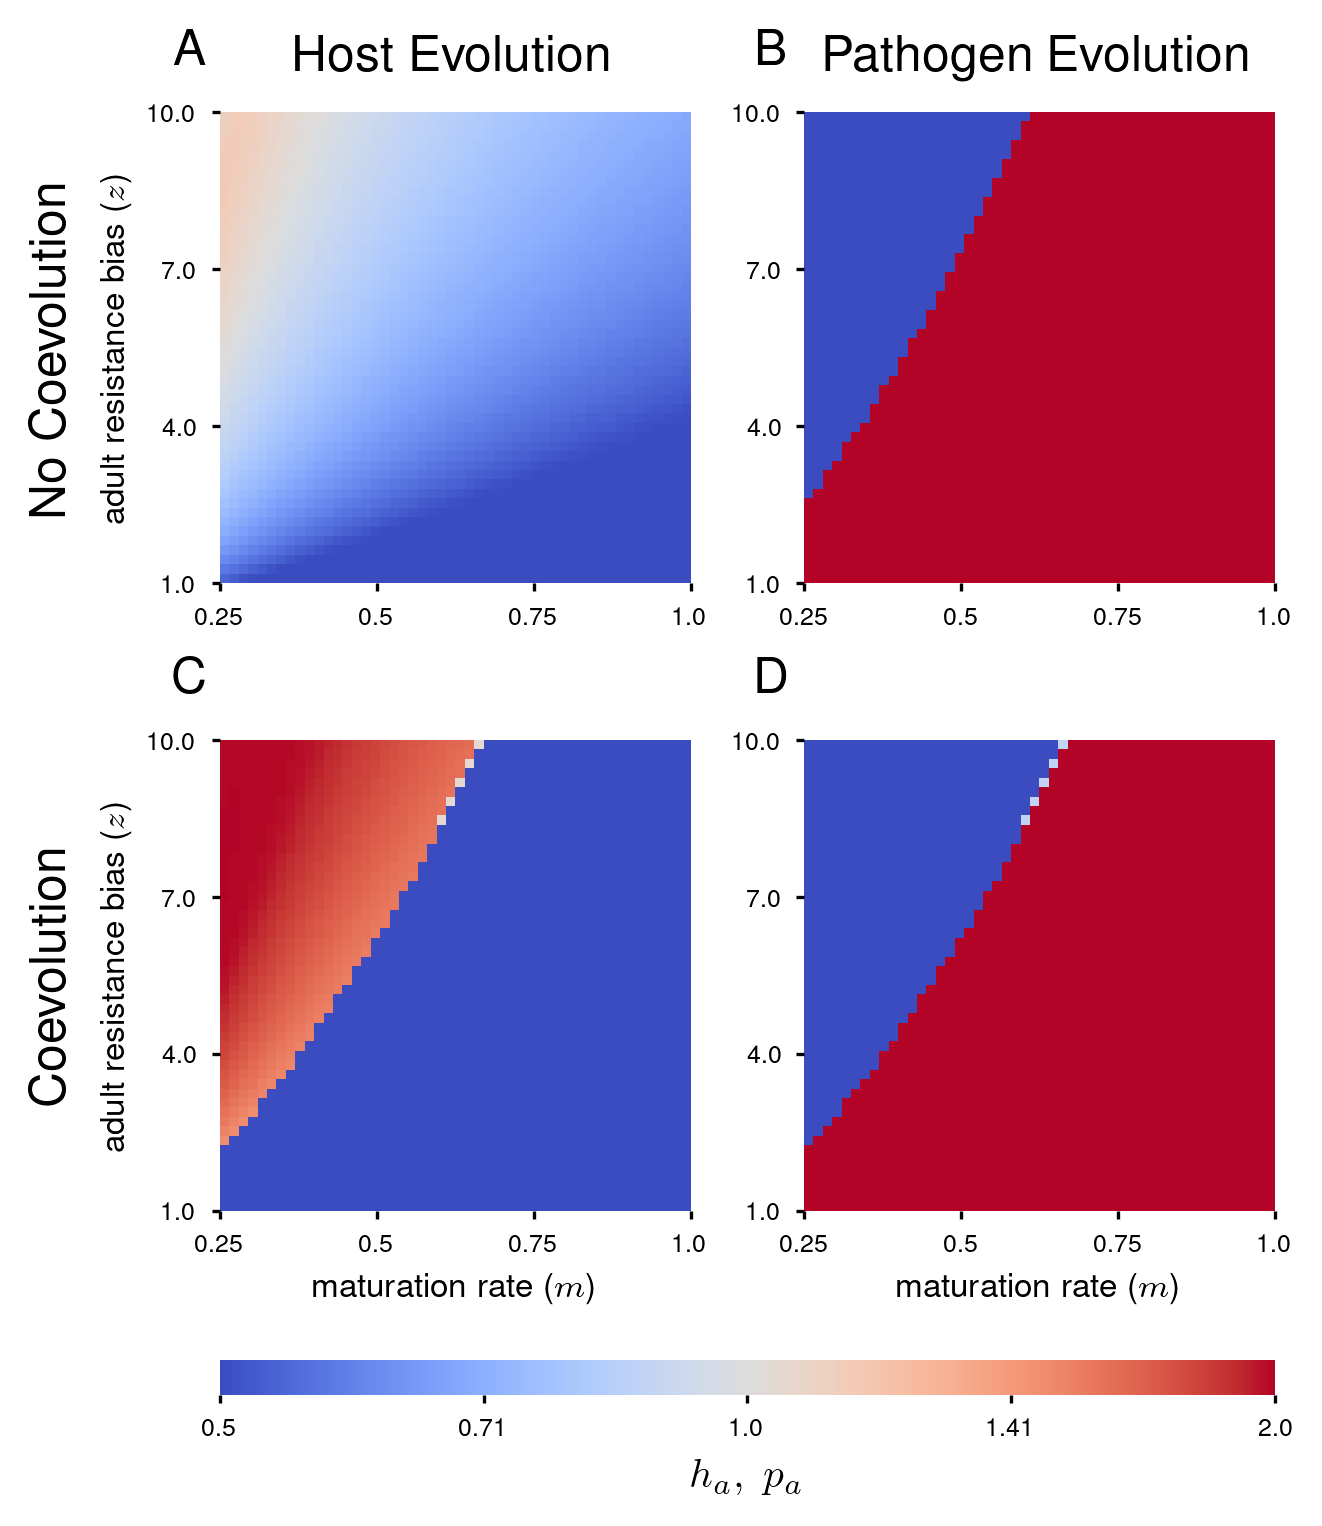

In [12]:
fig, ax = plt.subplots(figsize=(5,5), ncols=2, nrows=2, layout='compressed')

S_host, I_host = host_raster.evol_plot()
S_path, I_path, = path_raster.evol_plot()
S_coevol, I_coevol, = coevol_raster.evol_plot()

plot = ax[0,0].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
ax[0,1].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)
ax[1,0].imshow(99 - S_coevol, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

host_raster.label_axes(ax[0,0], (4, 4), label_x=False)
path_raster.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
coevol_raster.label_axes(ax[1,0], (4, 4))
coevol_raster.label_axes(ax[1,1], (4, 4), label_y=False)

ax[0,0].set_title('Host Evolution', pad=10)
ax[0,1].set_title('Pathogen Evolution', pad=10)
ax[0,0].annotate('No Coevolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=axis_title_size)
ax[1,0].annotate('Coevolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=axis_title_size)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
#cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


In [55]:
fig.savefig('figures/fig_3.svg', bbox_inches='tight')

## Figure 4: Ecological Implications

Text(-0.1, 1.1, 'D')

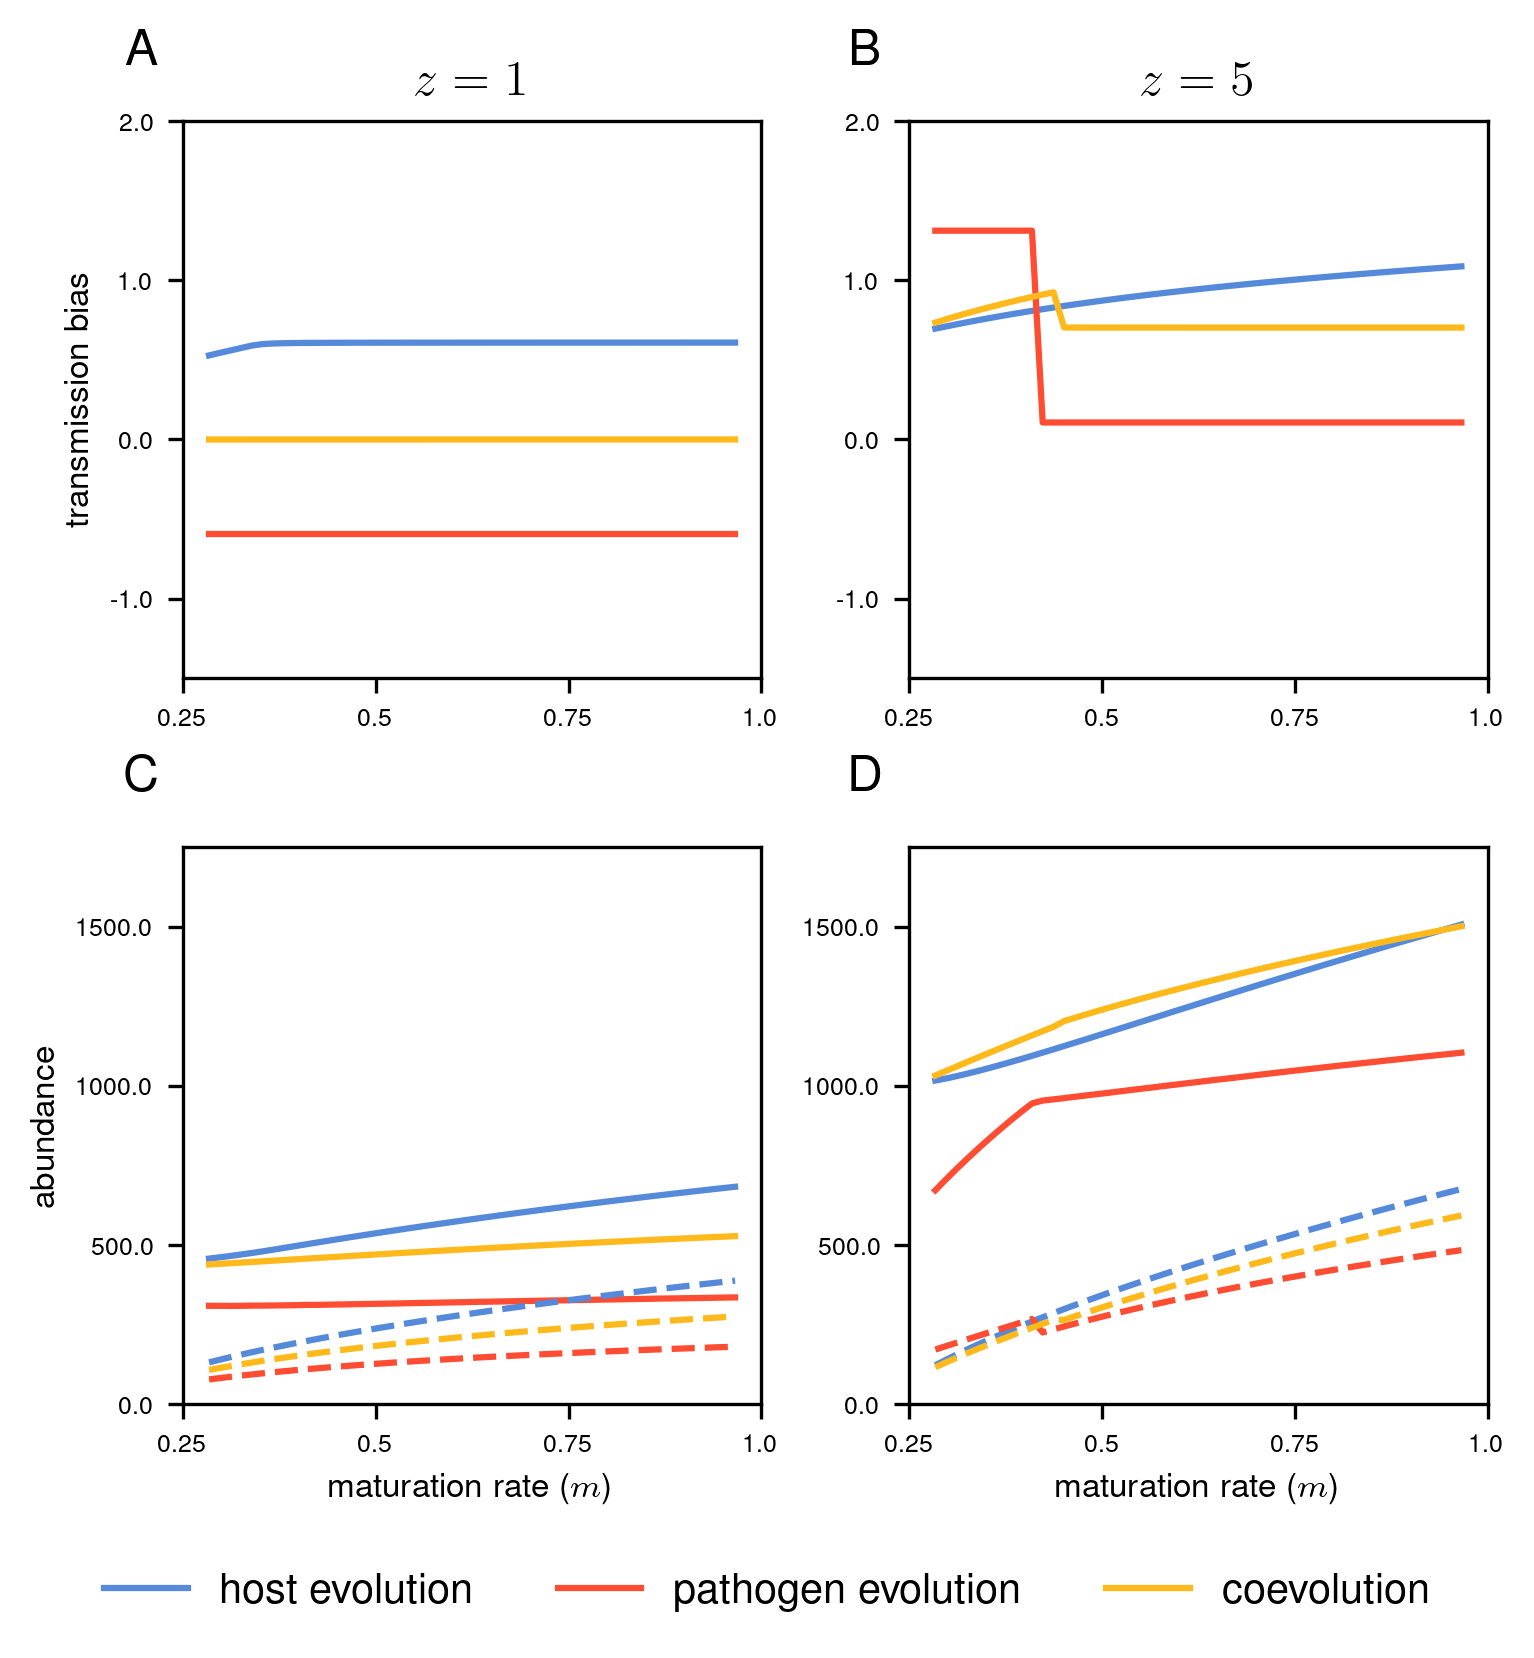

In [9]:
fig, ax = plt.subplots(figsize=(5, 5), ncols=2, nrows=2, layout='compressed')

z_1 = 1
z_2 = 5

ind_1 = np.argmin((coevol_raster.y_vals - z_1)**2)
ind_2 = np.argmin((coevol_raster.y_vals - z_2)**2)

def label_xaxis(ax, n_ticks=4):
    m_vals = coevol_raster.x_vals
    x_lim = ax.get_xlim()

    x_ticks = np.linspace(x_lim[0], x_lim[1], n_ticks)
    x_tick_labels = np.round(np.linspace(np.min(m_vals), np.max(m_vals), n_ticks), 3)
    
    ax.set_xticks(x_ticks, x_tick_labels)

betaj_host, betaa_host = host_raster.mean_transmission()
betaj_path, betaa_path = path_raster.mean_transmission()
betaj_coevol, betaa_coevol = coevol_raster.mean_transmission()

host_ratio = np.log10(betaj_host / betaa_host)
path_ratio = np.log10(betaj_path / betaa_path)
coevol_ratio = np.log10(betaj_coevol / betaa_coevol)

Sj_h, Sa_h, Ij_h, Ia_h = host_raster.abundance()
Sj_p, Sa_p, Ij_p, Ia_p = path_raster.abundance()
Sj_c, Sa_c, Ij_c, Ia_c = coevol_raster.abundance()

ax[0,0].plot(host_ratio[ind_1,:], label='host evolution', color=host_color)
ax[0,0].plot(path_ratio[ind_1,:], label='pathogen evolution', color=path_color)
ax[0,0].plot(coevol_ratio[ind_1,:], label='coevolution', color=coevol_color)

ax[0,1].plot(host_ratio[ind_2,:], label='host evolution', color=host_color)
ax[0,1].plot(path_ratio[ind_2,:], label='pathogen evolution', color=path_color)
ax[0,1].plot(coevol_ratio[ind_2,:], label='coevolution', color=coevol_color)

ax[1,0].plot((Sj_h+Sa_h+Ij_h+Ia_h)[ind_1,:], label='host evolution', color=host_color)
ax[1,0].plot((Sj_p+Sa_p+Ij_p+Ia_p)[ind_1,:], label='pathogen evolution', color=path_color)
ax[1,0].plot((Sj_c+Sa_c+Ij_c+Ia_c)[ind_1,:], label='coevolution', color=coevol_color)

ax[1,1].plot((Sj_h+Sa_h+Ij_h+Ia_h)[ind_2,:], label='host evolution', color=host_color)
ax[1,1].plot((Sj_p+Sa_p+Ij_p+Ia_p)[ind_2,:], label='pathogen evolution', color=path_color)
ax[1,1].plot((Sj_c+Sa_c+Ij_c+Ia_c)[ind_2,:], label='coevolution', color=coevol_color)

ax[1,0].plot((Ij_h + Ia_h)[ind_1,:], linestyle='--', label='host evolution', color=host_color)
ax[1,0].plot((Ij_p + Ia_p)[ind_1,:], linestyle='--', label='pathogen evolution', color=path_color)
ax[1,0].plot((Ij_c + Ia_c)[ind_1,:], linestyle='--', label='coevolution', color=coevol_color)

ax[1,1].plot((Ij_h + Ia_h)[ind_2,:], linestyle='--', label='host evolution', color=host_color)
ax[1,1].plot((Ij_p + Ia_p)[ind_2,:], linestyle='--', label='pathogen evolution', color=path_color)
ax[1,1].plot((Ij_c + Ia_c)[ind_2,:], linestyle='--', label='coevolution', color=coevol_color)

ax[0,0].set_ylim(-1.5, 2)
ax[0,1].set_ylim(-1.5, 2)

ax[1,0].set_ylim(0, 1750)
ax[1,1].set_ylim(0, 1750)

for axis in ax.reshape(-1):
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

ax[0,0].set_title(r'$z=1$')
ax[0,1].set_title(r'$z=5$')

ax[0,0].set_ylabel('transmission bias')
ax[1,0].set_ylabel('abundance')

ax[1,0].set_xlabel(r'maturation rate ($m$)')
ax[1,1].set_xlabel(r'maturation rate ($m$)')

for axis in ax.reshape(-1): label_xaxis(axis)

lines, labels = ax[0,0].get_legend_handles_labels()
fig.legend(lines, labels, ncol=3, loc='center', bbox_to_anchor=(0.5, -0.05), frameon=False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

In [49]:
fig.savefig('figures/fig_4.svg', bbox_inches='tight')

Text(-0.2, 1.1, 'C')

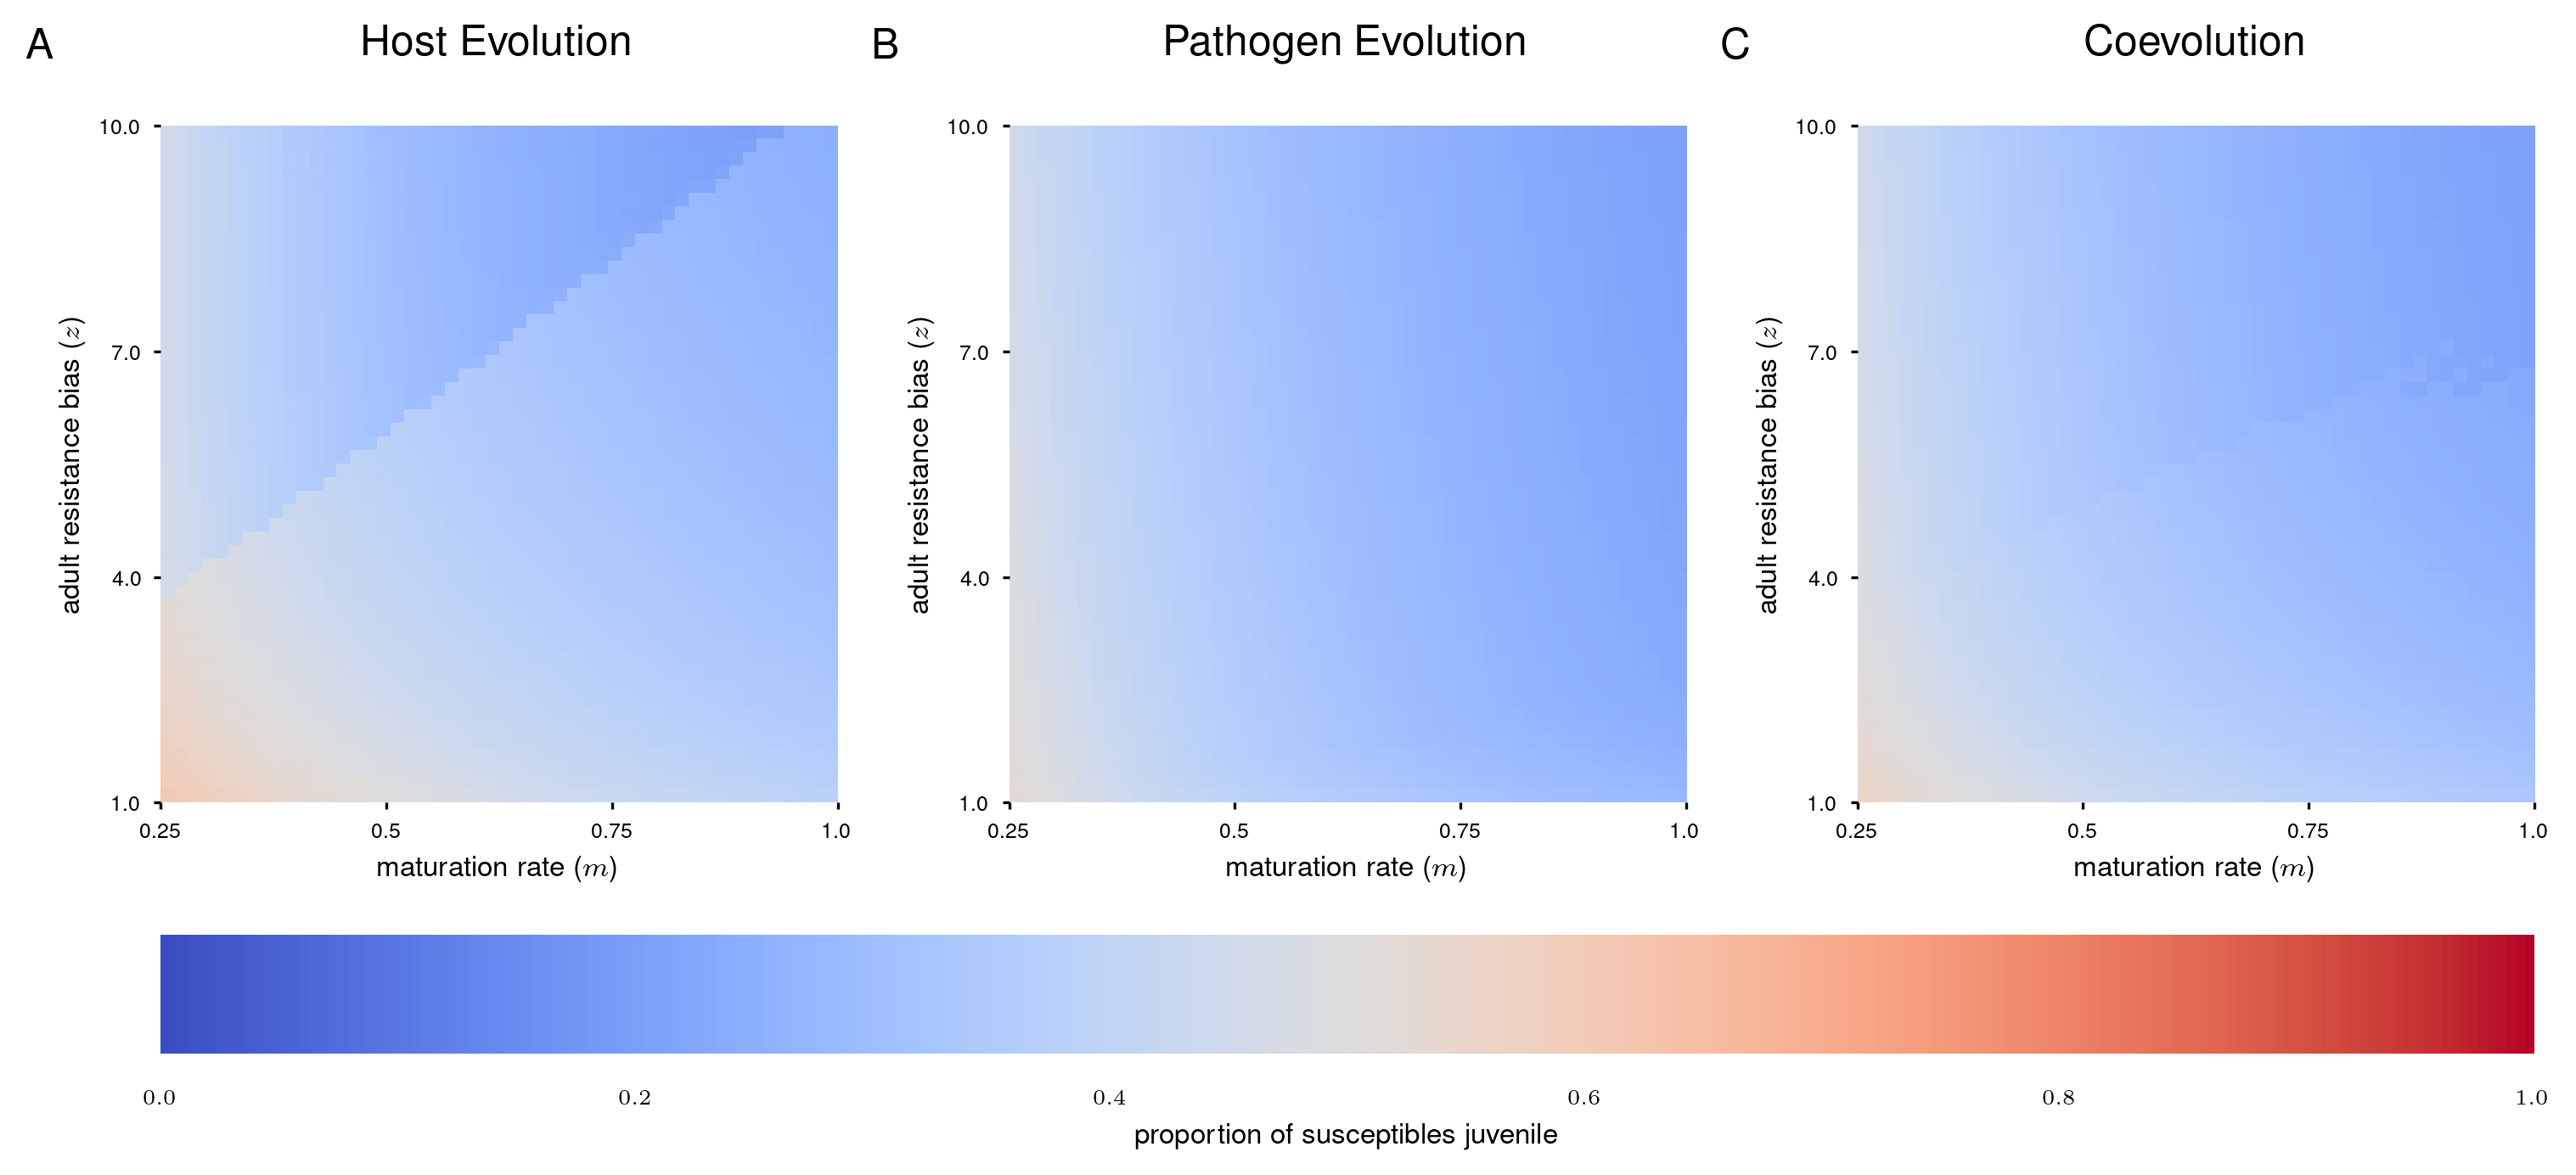

In [50]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(10,5), layout='constrained')

Sj_p, Sa_p, Ij_p, Ia_p = host_raster.abundance()
Sj_h, Sa_h, Ij_h, Ia_h = path_raster.abundance()
Sj_c, Sa_c, Ij_c, Ia_c = coevol_raster.abundance()

Sj_prop_host = Sj_h / (Sj_h+Sa_h)
Sj_prop_path = Sj_p / (Sj_p+Sa_p)
Sj_prop_coevol = Sj_c / (Sj_c+Sa_c)

ax[0].imshow(Sj_prop_host, cmap='coolwarm', vmin=0, vmax=1)
ax[1].imshow(Sj_prop_path, cmap='coolwarm', vmin=0, vmax=1)
plot = ax[2].imshow(Sj_prop_coevol, cmap='coolwarm', vmin=0, vmax=1)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

host_raster.label_axes(ax[0], (4,4))
path_raster.label_axes(ax[1], (4,4))
coevol_raster.label_axes(ax[2], (4,4))

ax[0].set_title('Host Evolution', pad=20)
ax[1].set_title('Pathogen Evolution', pad=20)
ax[2].set_title('Coevolution', pad=20)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom')
cbar.ax.tick_params(axis='both', which='both', length=0, pad=10)
cbar.set_label(r'proportion of susceptibles juvenile')
cbar.outline.set_visible(False)

ax[0].annotate("A", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

Text(-0.2, 1.1, 'C')

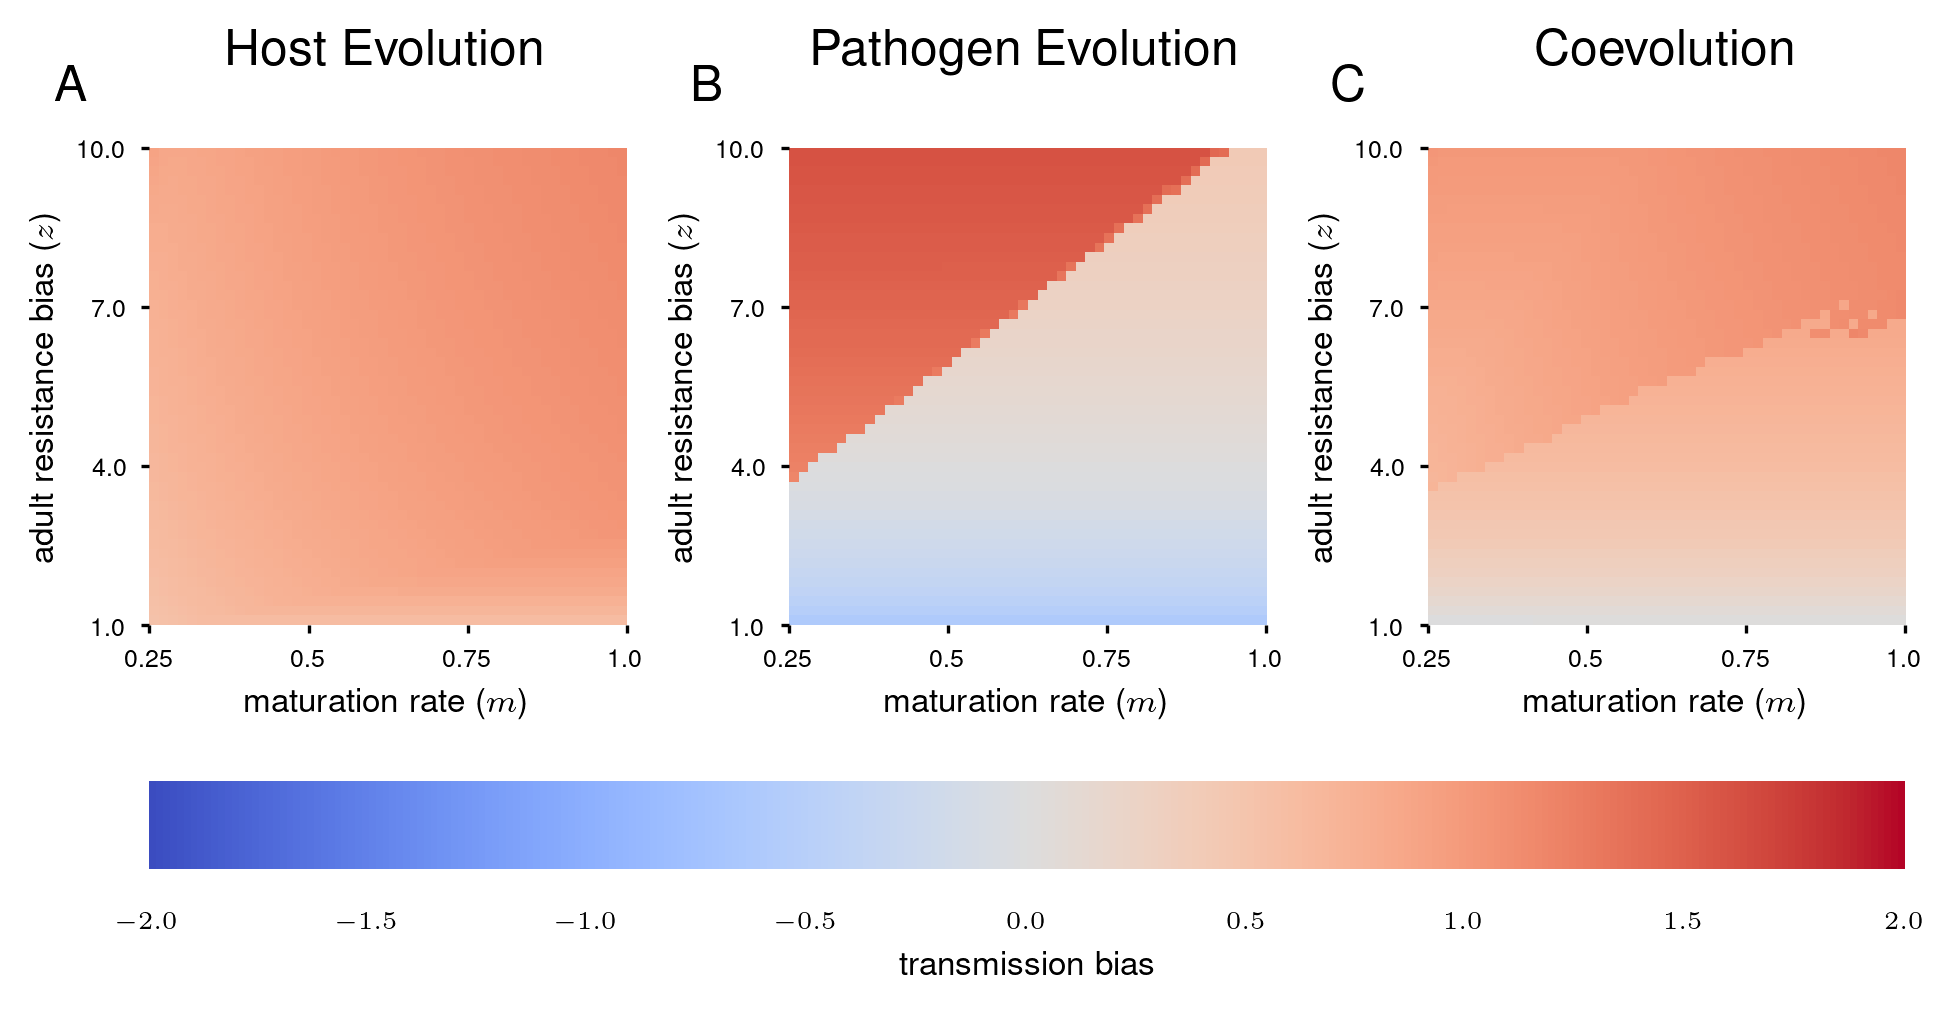

In [51]:
fig, ax = plt.subplots(ncols=3, layout='constrained')

betaj_host, betaa_host = host_raster.mean_transmission()
betaj_path, betaa_path = path_raster.mean_transmission()
betaj_coevol, betaa_coevol = coevol_raster.mean_transmission()

host_ratio = np.log10(betaj_host / betaa_host)
path_ratio = np.log10(betaj_path / betaa_path)
coevol_ratio = np.log10(betaj_coevol / betaa_coevol)

evol_plot = ax[0].imshow(host_ratio, cmap='coolwarm', vmin=-2, vmax=2)
ax[1].imshow(path_ratio, cmap='coolwarm', vmin=-2, vmax=2)
ax[2].imshow(coevol_ratio, cmap='coolwarm', vmin=-2, vmax=2)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

host_raster.label_axes(ax[0], (4,4))
path_raster.label_axes(ax[1], (4,4))
coevol_raster.label_axes(ax[2], (4,4))

ax[0].set_title('Host Evolution', pad=20)
ax[1].set_title('Pathogen Evolution', pad=20)
ax[2].set_title('Coevolution', pad=20)

cbar = fig.colorbar(evol_plot, ax=ax[:], location='bottom')
cbar.ax.tick_params(axis='both', which='both', length=0, pad=10)
cbar.set_label(r'transmission bias')
cbar.outline.set_visible(False)

ax[0].annotate("A", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

Text(-0.2, 1.1, 'C')

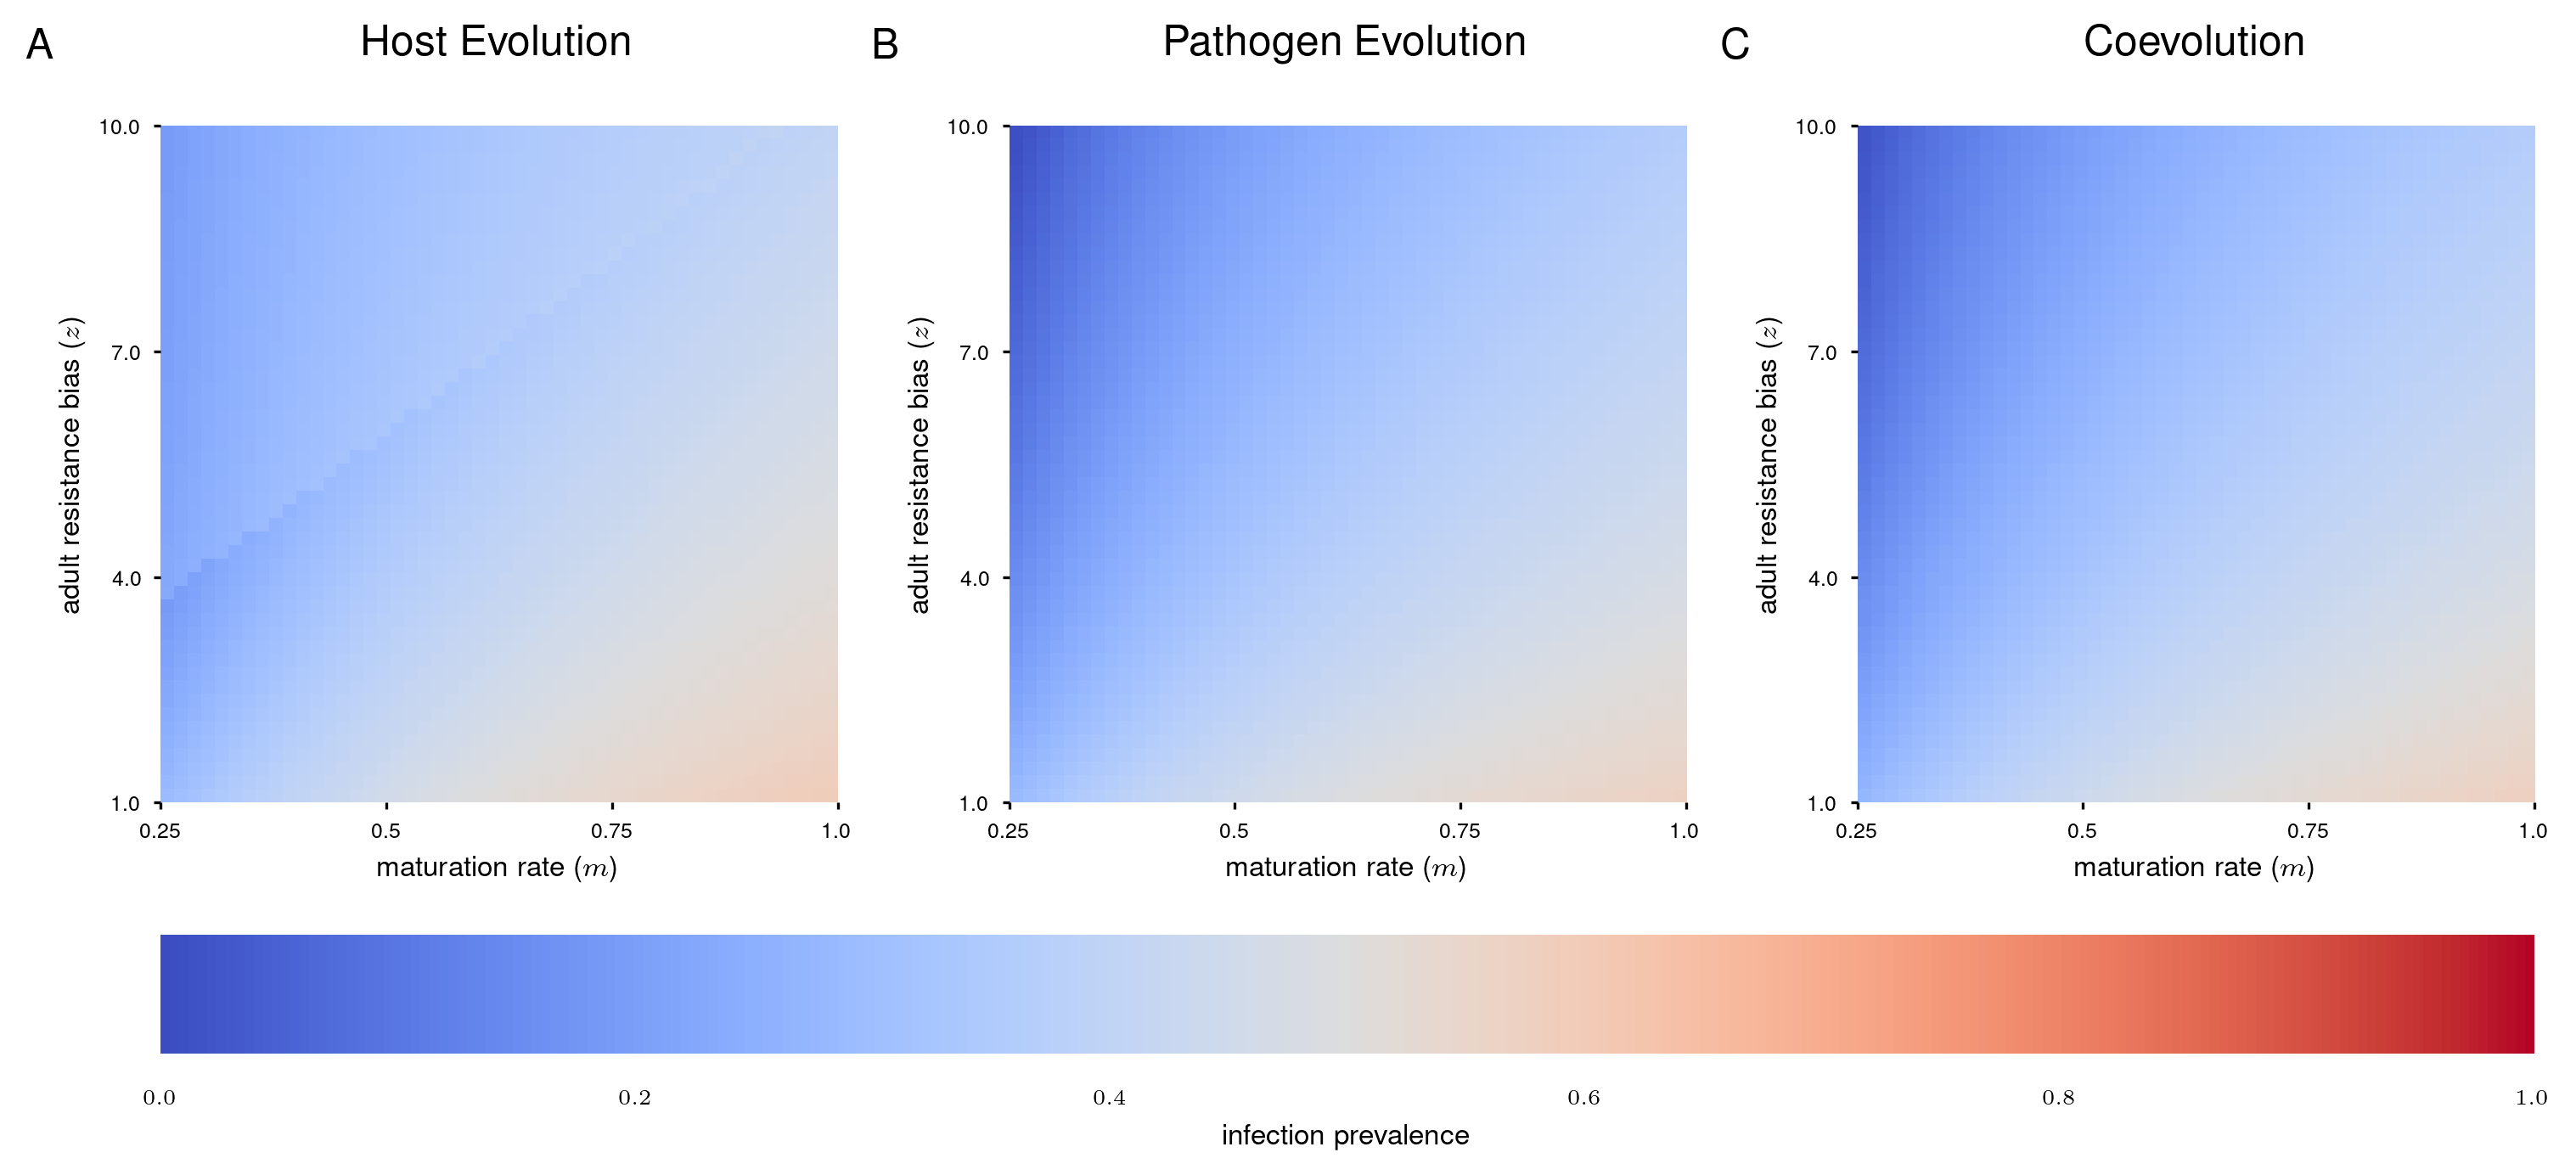

In [52]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(10,5), layout='constrained')

Sj_p, Sa_p, Ij_p, Ia_p = host_raster.abundance()
Sj_h, Sa_h, Ij_h, Ia_h = path_raster.abundance()
Sj_c, Sa_c, Ij_c, Ia_c = coevol_raster.abundance()

ax[0].imshow((Ij_h+Ia_h)/(Sj_h+Sa_h+Ij_h+Ia_h), cmap='coolwarm', vmin=0, vmax=1)
ax[1].imshow((Ij_p+Ia_p)/(Sj_p+Sa_p+Ij_p+Ia_p), cmap='coolwarm', vmin=0, vmax=1)
coevol_plot = ax[2].imshow((Ij_c+Ia_c)/(Sj_c+Sa_c+Ij_c+Ia_c), cmap='coolwarm', vmin=0, vmax=1)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

host_raster.label_axes(ax[0], (4,4))
path_raster.label_axes(ax[1], (4,4))
coevol_raster.label_axes(ax[2], (4,4))

ax[0].set_title('Host Evolution', pad=20)
ax[1].set_title('Pathogen Evolution', pad=20)
ax[2].set_title('Coevolution', pad=20)

cbar = fig.colorbar(coevol_plot, ax=ax[:], location='bottom')
cbar.ax.tick_params(axis='both', which='both', length=0, pad=10)
cbar.set_label(r'infection prevalence')
cbar.outline.set_visible(False)

ax[0].annotate("A", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.2, 1.1), xycoords="axes fraction", fontsize=plot_label_size)